VERSION 2023/03/06
- Try combine u1 and u2
- ** FIX H **


In [ ]:
import numpy as np
import tensorflow as tf
import math
import matplotlib.pyplot as plt

1) Set all parameters

In [ ]:
No_bit = 100
test_size = 1000000
#SNR_db = np.array([70,80,90,100,110,120]) #70
SNR_db = np.arange(70, 112, 2)
BER_u1 = np.zeros(len(SNR_db))
BER_u2 = np.zeros(len(SNR_db))

d1 = 0.015   #Distance from BS to UE1 in km == 15 m.
d2 = 0.005 #Distance from BS to UE2 in km -- 5 m.
f = 2.4 #Carrier frequency in GHz
a1 = 0.8  #Power allocation of user1
a2 = 0.2  #Power allocation of user2

2) Path Loss Calculation

In [ ]:
#Generate channel for user 1
Lp1_dB = 92.4 + 20*math.log10(f) + 20*math.log10(d1) #Large scale for user2 in dB
Lp1 = pow(10,(Lp1_dB/10)); #Large scale in Linear

#Generate channel
Lp2_dB = 92.4 + 20*math.log10(f) + 20*math.log10(d2) #Large scale for user2 in dB
Lp2 = pow(10,(Lp2_dB/10)); #Large scale in Linear


3) Generate Rayleigh Channel Coef

In [ ]:
#FIX CHANNEL
h_real_random = (np.random.randn(1, No_bit))
h_real = np.mean(h_real_random)
#h_real_u1 = h_real / math.sqrt(2*Lp1)

h_imag_random = (np.random.randn(1, No_bit))
h_imag = np.mean(h_imag_random)
#h_imag = h_imag / math.sqrt(2)


4) Generate random binary data vector for two users with size  

In [ ]:
def data_generate(No_bit):
    data = np.random.randint(0, 2, size=(No_bit))

    label = data.reshape(len(data), 1)
    #label = tf.keras.utils.to_categorical(label)

    return data, label

5) Do BPSK modulation of data

6) Do superposition coding

In [ ]:
def SPC_generate(No_bit):
  data_u1, label_u1 = data_generate(No_bit)
  data_u2, label_u2 = data_generate(No_bit)

  symbol1 = 2*data_u1 - 1
  symbol2 = 2*data_u2 - 1

  label_u1 = label_u1
  label_u2 = label_u2

  SPC = math.sqrt(a1)*symbol1 + math.sqrt(a2)*symbol2

  return SPC, label_u1, label_u2

7) Generate noise samples for far users.

In [ ]:
def noise_generate(No_bit):
  w_real = (np.random.randn(1, No_bit))
  w_real = w_real / math.sqrt(2)

  w_imag = (np.random.randn(1, No_bit))
  w_imag =  w_imag / math.sqrt(2)

  return w_real, w_imag

In [ ]:
#def channel_generate(No_bit, Lpi):
  #h_real = (np.random.randn(1, No_bit))
  #h_real = math.sqrt(1/2*Lpi)*h_real

  #h_imag = (np.random.randn(1, No_bit))
  #h_imag = math.sqrt(1/2*Lpi)*h_imag

  #return h_real, h_imag

8) Received Signal

In [ ]:
def received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2):

    w_real_u1, w_imag_u1 = noise_generate(No_bit)
    w_real_u2, w_imag_u2 = noise_generate(No_bit)

    #Received signal
    #y = h*SPC + sigma*w

    h_real_u1 = h_real/math.sqrt(2*Lp1)
    h_imag_u1 = h_imag/math.sqrt(2*Lp1)

    y_real_u1 = h_real_u1*SPC + sigma*w_real_u1
    y_imag_u1 = h_imag_u1*SPC + sigma*w_imag_u1

    h_real_u2 = h_real/math.sqrt(2*Lp2)
    h_imag_u2 = h_imag/math.sqrt(2*Lp2)

    y_real_u2 = h_real_u2*SPC + sigma*w_real_u2
    y_imag_u2 = h_imag_u2*SPC + sigma*w_imag_u2

    y_signal_u1 = np.transpose(np.concatenate((y_real_u1, y_imag_u1), axis=0))
    y_signal_u2 = np.transpose(np.concatenate((y_real_u2, y_imag_u2), axis=0))

    return y_signal_u1, y_signal_u2

9) Model U1 (Far User)

In [ ]:
from tensorflow import keras
from keras.layers import Dense, Dropout, BatchNormalization
from keras.models import Sequential

# define classification model
def DNN_model_u1():
    # create model
    model = Sequential()

    #model.add(Dense(8, input_dim = len(x_train[0,:]), activation='relu'))
    model.add(Dense(8, input_dim = 2, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(4, activation='relu'))
    model.add(BatchNormalization())
    #model.add(Dropout(0.4))

    model.add(Dense(2, activation='relu'))
    model.add(BatchNormalization())
    #model.add(Dropout(0.4))

    model.add(Dense(2, activation='relu'))
    model.add(BatchNormalization())
    #model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    # compile model
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
model_u1 = DNN_model_u1()
model_u1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 24        
                                                                 
 batch_normalization (BatchN  (None, 8)                32        
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 4)                 36        
                                                                 
 batch_normalization_1 (Batc  (None, 4)                16        
 hNormalization)                                                 
                                                                 
 dense_2 (Dense)             (None, 2)                 10        
                                                                 
 batch_normalization_2 (Batc  (None, 2)                8

10) Model U2 (Near User)

In [ ]:
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import BatchNormalization

# define classification model
def DNN_model_u2():
    # create model
    model = Sequential()

    #model.add(Dense(8, input_dim = len(x_train[0,:]), activation='relu'))
    model.add(Dense(16, input_dim = 3, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(8, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(4, activation='relu'))
    model.add(BatchNormalization())
    #model.add(Dropout(0.4))

    model.add(Dense(4, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(2, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    # compile model
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics=['accuracy'])

    #model.compile(optimizer='adam', loss = 'mse', metrics=['accuracy'])

    return model

In [ ]:
model_u2 = DNN_model_u2()
model_u2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 16)                64        
                                                                 
 batch_normalization_4 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dense_6 (Dense)             (None, 8)                 136       
                                                                 
 batch_normalization_5 (Batc  (None, 8)                32        
 hNormalization)                                                 
                                                                 
 dropout (Dropout)           (None, 8)                 0         
                                                                 
 dense_7 (Dense)             (None, 4)                

11) Model U1 Training (Focus only decoding U1 data)

Input to DNN

*   user 1 received signal (real part)
*   user 1 received signal (imag part)

Also need to normalize the input feature

In [ ]:
for i in range(len(SNR_db)):
  SPC, label1, label2 = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_signal_u1, y_signal_u2 = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2)

  #Normalize Input feature
  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  y_signal_u1_norm = scaler.fit_transform(y_signal_u1)
  print("Training at SNR", SNR_db[i])

  #x_train =  np.concatenate((y_signal, label1), axis=1)
  x_train_u1 = y_signal_u1_norm
  y_train_u1 = label1

  from sklearn.model_selection import train_test_split
  x_train, x_validate, y_train, y_validate = train_test_split(x_train_u1, y_train_u1, test_size=0.3, random_state=None)
  model_trained = model_u1.fit(x_train, y_train, validation_data=(x_validate, y_validate), epochs = 100, verbose = 0)


Training at SNR 70
Training at SNR 72
Training at SNR 74
Training at SNR 76
Training at SNR 78
Training at SNR 80
Training at SNR 82
Training at SNR 84
Training at SNR 86
Training at SNR 88
Training at SNR 90
Training at SNR 92
Training at SNR 94
Training at SNR 96
Training at SNR 98
Training at SNR 100
Training at SNR 102
Training at SNR 104
Training at SNR 106
Training at SNR 108
Training at SNR 110


12) Model U1 Testing

In [ ]:
for i in range(len(SNR_db)):
  SPC_test, test_label1, test_label2 = SPC_generate(test_size)
  signal_power = np.mean(pow(SPC_test, 2))
  #SNR_linear = pow(10, SNR_db[i]/10)
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_signal_test_u1, y_signal_test_u2 = received_signal(SPC_test, test_size, sigma, h_real, h_imag, Lp1, Lp2)

  #Norm
  ytest_u1_norm = scaler.fit_transform(y_signal_test_u1)

  print("Testing at SNR", SNR_db[i], "dB")

  #x_test =  np.concatenate((y_signal_test, test_label1), axis=1)
  x_test_u1 = ytest_u1_norm
  y_test_u1 = test_label1
  model_u1.evaluate(x_test_u1, y_test_u1)


Testing at SNR 70 dB
31250/31250 [==============================] - 62s 2ms/step - loss: 2.0047 - accuracy: 0.5549
Testing at SNR 72 dB
31250/31250 [==============================] - 70s 2ms/step - loss: 1.9348 - accuracy: 0.5687
Testing at SNR 74 dB
31250/31250 [==============================] - 61s 2ms/step - loss: 1.8467 - accuracy: 0.5859
Testing at SNR 76 dB
31250/31250 [==============================] - 62s 2ms/step - loss: 1.7375 - accuracy: 0.6076
Testing at SNR 78 dB
31250/31250 [==============================] - 61s 2ms/step - loss: 1.6076 - accuracy: 0.6337
Testing at SNR 80 dB
31250/31250 [==============================] - 62s 2ms/step - loss: 1.4519 - accuracy: 0.6647
Testing at SNR 82 dB
31250/31250 [==============================] - 61s 2ms/step - loss: 1.2700 - accuracy: 0.7015
Testing at SNR 84 dB
31250/31250 [==============================] - 60s 2ms/step - loss: 1.0742 - accuracy: 0.7416
Testing at SNR 86 dB
31250/31250 [==============================] - 63s 2ms/step

13) Model U2 Training

Input to DNN

*   user 2 received signal (real part)
*   user 2 received signal (imag part)

*   Prediction of user 1 detection bit from model u1






In [ ]:
for i in range(len(SNR_db)):
  SPC, label1, label2 = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_signal_u1, y_signal_u2 = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2)

  y_signal_u1_norm = scaler.fit_transform(y_signal_u1)
  y_training_u2_norm = scaler.fit_transform(y_signal_u2)

  #Use the model we have already trained to predict the u1 data
  #Also collect ihe info to plot the BER of u1
  pred_u1 = model_u1.predict(y_signal_u1_norm)
  pred_u1 = pred_u1.round()

  #y_signal_u2 = received_signal(SPC, No_bit, sigma, h_real_u2, h_imag_u2)
  print("Training at SNR", SNR_db[i])

  x_train_u2 = np.concatenate((y_training_u2_norm, pred_u1), axis=1)
  y_train_u2 = label2

  from sklearn.model_selection import train_test_split
  x_train_u2, x_validate_u2, y_train_u2, y_validate_u2 = train_test_split(x_train_u2, y_train_u2, test_size=0.3, random_state=None)
  model_u2_train = model_u2.fit(x_train_u2, y_train_u2, validation_data=(x_validate_u2, y_validate_u2), epochs = 100, verbose = 0)
  #model_trained = model.fit(x_train, y_train, epochs = 1000, verbose = 2)


4/4 [==============================] - 0s 3ms/step
Training at SNR 70
4/4 [==============================] - 0s 4ms/step
Training at SNR 72
4/4 [==============================] - 0s 4ms/step
Training at SNR 74
4/4 [==============================] - 0s 3ms/step
Training at SNR 76
4/4 [==============================] - 0s 4ms/step
Training at SNR 78
4/4 [==============================] - 0s 4ms/step
Training at SNR 80
4/4 [==============================] - 0s 3ms/step
Training at SNR 82
4/4 [==============================] - 0s 3ms/step
Training at SNR 84
4/4 [==============================] - 0s 5ms/step
Training at SNR 86
4/4 [==============================] - 0s 3ms/step
Training at SNR 88
4/4 [==============================] - 0s 4ms/step
Training at SNR 90
4/4 [==============================] - 0s 4ms/step
Training at SNR 92
4/4 [==============================] - 0s 4ms/step
Training at SNR 94
4/4 [==============================] - 0s 3ms/step
Training at SNR 96
4/4 [===============

14) Model U2 Testing

In [ ]:
for i in range(len(SNR_db)):
  SPC_test, test_label1, test_label2 = SPC_generate(test_size)
  signal_power = np.mean(pow(SPC_test, 2))
  #SNR_linear = pow(10, SNR_db[i]/10)
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_signal_test_u1, y_signal_test_u2 = received_signal(SPC_test, test_size, sigma, h_real, h_imag, Lp1, Lp2)

  ytesting_u1_norm = scaler.fit_transform(y_signal_test_u1)
  ytesting_u2_norm = scaler.fit_transform(y_signal_test_u2)

  #loaded_model_test = keras.models.load_model('/content/model_u1.h5')
  #pred_u1_test = loaded_model_test.predict(y_signal_test_u1)
  pred_u1_test = model_u1.predict(ytesting_u1_norm)
  pred_u1_test = pred_u1_test.round()
  diff_u1 = np.not_equal(pred_u1_test, test_label1)
  error_count_u1 = np.sum(diff_u1)
  BER_u1[i] = error_count_u1/len(test_label1)

  print("Testing at SNR", SNR_db[i], "dB")

  x_test = np.concatenate((ytesting_u2_norm, pred_u1_test), axis=1)
  y_test = test_label2
  model_u2.evaluate(x_test, y_test)

  pred_u2 = model_u2.predict(x_test)
  pred_u2 = pred_u2.round()
  diff_u2 = np.not_equal(pred_u2, test_label2)
  error_count_u2 = np.sum(diff_u2)
  BER_u2[i] = error_count_u2/len(test_label2)


31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 70 dB
31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 72 dB
31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 74 dB
31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 76 dB
31250/31250 [==============================] - 55s 2ms/step
Testing at SNR 78 dB
31250/31250 [==============================] - 56s 2ms/step
Testing at SNR 80 dB
31250/31250 [==============================] - 55s 2ms/step
Testing at SNR 82 dB
31250/31250 [==============================] - 56s 2ms/step
Testing at SNR 84 dB
31250/31250 [==============================] - 56s 2ms/step
Testing at SNR 86 dB
31250/31250 [==============================] - 57s 2ms/step
Testing at SNR 88 dB
31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 90 dB
31250/31250 [==============================] - 54s 2ms/step
Testing at SNR 92 dB
31250/31250 [===============

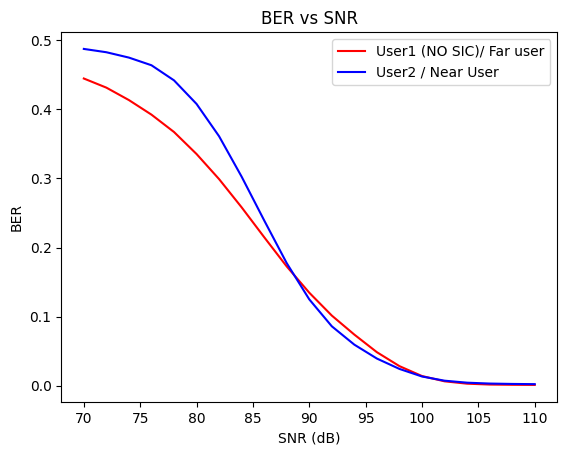

In [ ]:
plt.plot(SNR_db, BER_u1, color='r', label='User1 (NO SIC)/ Far user')
plt.plot(SNR_db, BER_u2, color='b', label='User2 / Near User')
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR")
plt.legend()
plt.show()

In [ ]:
BER_u1

array([0.44475 , 0.431518, 0.413508, 0.392415, 0.36728 , 0.335387,
       0.299035, 0.258173, 0.214956, 0.172564, 0.134567, 0.101431,
       0.073864, 0.048401, 0.028221, 0.013888, 0.006245, 0.002838,
       0.001576, 0.001223, 0.00103 ])

In [ ]:
BER_u2

array([0.487589, 0.482783, 0.475021, 0.463928, 0.44206 , 0.407921,
       0.36108 , 0.302561, 0.239246, 0.177343, 0.124911, 0.085904,
       0.059314, 0.039194, 0.024195, 0.013225, 0.007165, 0.004268,
       0.003005, 0.002451, 0.002144])

In [ ]:
#(1x2) NOMA
#ML to optimize power allocation , minimize maximum BER
#vary power, bit , noise
